<a href="https://colab.research.google.com/github/arsha-analyst/Telco-Customer-Churn-Analysis/blob/main/Clustering_Analysis/cluster_analysis_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
sns.set_style("white")
import warnings
warnings.filterwarnings('ignore')

# Data Ingension

In [11]:

data=pd.read_csv('/content/drive/MyDrive/Data_V3.csv')
X_encoded_df=pd.read_csv('/content/drive/MyDrive/X_encoded_df.csv')
X_train=pd.read_csv('/content/drive/MyDrive/X_train.csv')

# Clustering Model and Analysis

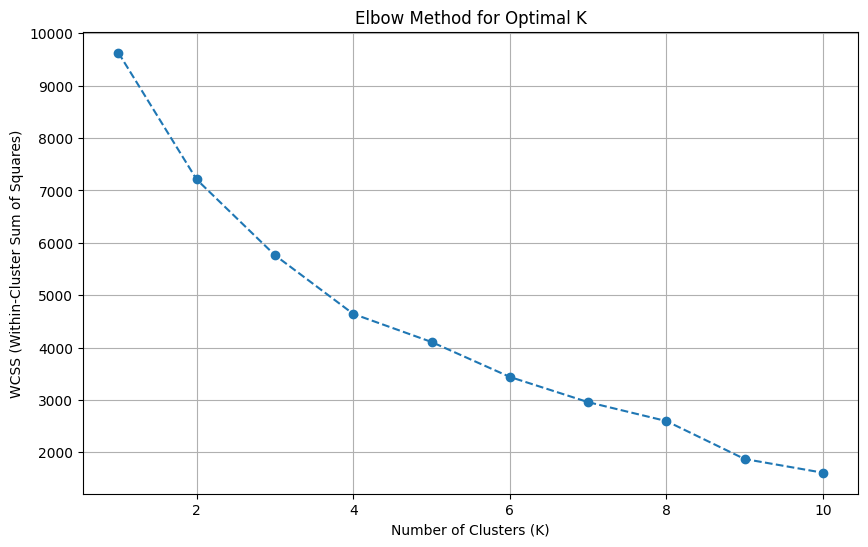

In [12]:
wcss = []
# test K from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

In [99]:
# the elbow is at 4, so optinmal clusters is 4
optimal_k = 4

# initialize and fit K-Means model on encoded dataset
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_encoded_df)

# cluster labels to the original data for profiling
data['Cluster'] = cluster_labels

print(f"K-Means model fitted with {optimal_k} clusters.")
print("First 5 rows with assigned clusters:")
display(data.head())

K-Means model fitted with 4 clusters.
First 5 rows with assigned clusters:


,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,MonthlyCharges,Churn,Tenure_Groups,MonthlyCharges_Groups,Cluster
0,Female,0,No,1,No,No,DSL,Month-to-month,25,Yes,Short (0-12m),Low ($0-$35),0
1,Male,0,No,41,Yes,No,DSL,One year,25,No,Mid-term (13-48m),Low ($0-$35),3
2,Female,0,Yes,52,Yes,No,DSL,Month-to-month,19,No,Long (49-72m),Low ($0-$35),1
3,Female,0,No,1,Yes,No,DSL,One year,76,Yes,Short (0-12m),High ($70.01+),0
4,Male,0,No,67,Yes,No,Fiber optic,Month-to-month,51,No,Long (49-72m),Medium ($35.01-$70),2


In [23]:
print("\nCluster Profiling based on Dependents:")
display(pd.crosstab(data['Cluster'], data['Dependents'], normalize='index') * 100)

print("\nCluster Profiling based on Tenure Groups:")
display(pd.crosstab(data['Cluster'], data['Tenure_Groups'], normalize='index') * 100)

print("\nCluster Profiling based on Monthly Charges Groups:")
display(pd.crosstab(data['Cluster'], data['MonthlyCharges_Groups'], normalize='index') * 100)

# the average Churn rate within each cluster
print("\nAverage Churn Rate per Cluster:")
display(data.groupby('Cluster')['Churn'].value_counts(normalize=True).unstack() * 100)


Cluster Profiling based on Dependents:


Dependents,No,Yes
Cluster,,
0,100.000000,0.000000
1,0.000000,100.000000
2,74.676724,25.323276
3,100.000000,0.000000



Cluster Profiling based on Tenure Groups:


Tenure_Groups,Long (49-72m),Mid-term (13-48m),Short (0-12m)
Cluster,,,
0,0.000000,0.000000,100.000000
1,23.353659,49.573171,27.073171
2,100.000000,0.000000,0.000000
3,0.000000,100.000000,0.000000



Cluster Profiling based on Monthly Charges Groups:


MonthlyCharges_Groups,High ($70.01+),Low ($0-$35),Medium ($35.01-$70)
Cluster,,,
0,41.102181,26.176808,32.721010
1,25.121951,42.743902,32.134146
2,74.299569,12.661638,13.038793
3,54.515235,20.332410,25.152355



Average Churn Rate per Cluster:


Churn,No,Yes
Cluster,,
0,48.966705,51.033295
1,82.865854,17.134146
2,88.900862,11.099138
3,72.686981,27.313019


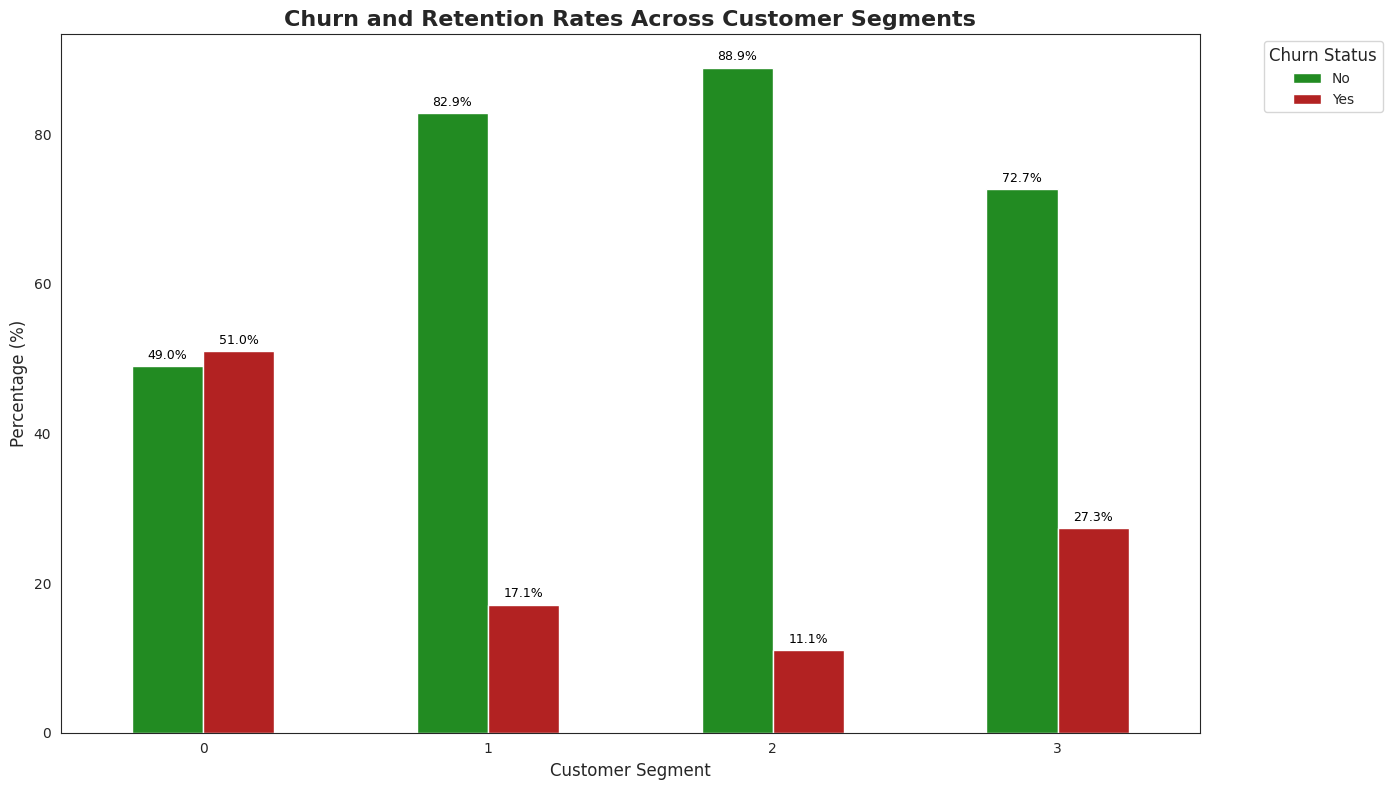

In [97]:
churn_by_cluster = data.groupby('Cluster')['Churn'].value_counts(normalize=True).unstack() * 100

# define custom colors: green for 'No' (retained) and red for 'Yes' (churn)
colors = {'No': 'forestgreen', 'Yes': 'firebrick'}

fig = plt.figure(figsize=(14, 8))
ax = churn_by_cluster.plot(kind='bar', stacked=False, ax=plt.gca(), color=[colors[col] for col in churn_by_cluster.columns])
plt.title('Churn and Retention Rates Across Customer Segments', fontsize=16, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(fontsize=10)
plt.xticks(fontsize=10)
plt.legend(title='Churn Status', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, fontsize=10, title_fontsize=12)

# add percentage labels on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9, color='black', padding=3)

plt.tight_layout()
plt.show()

### Cluster Profiling Visualizations by Feature



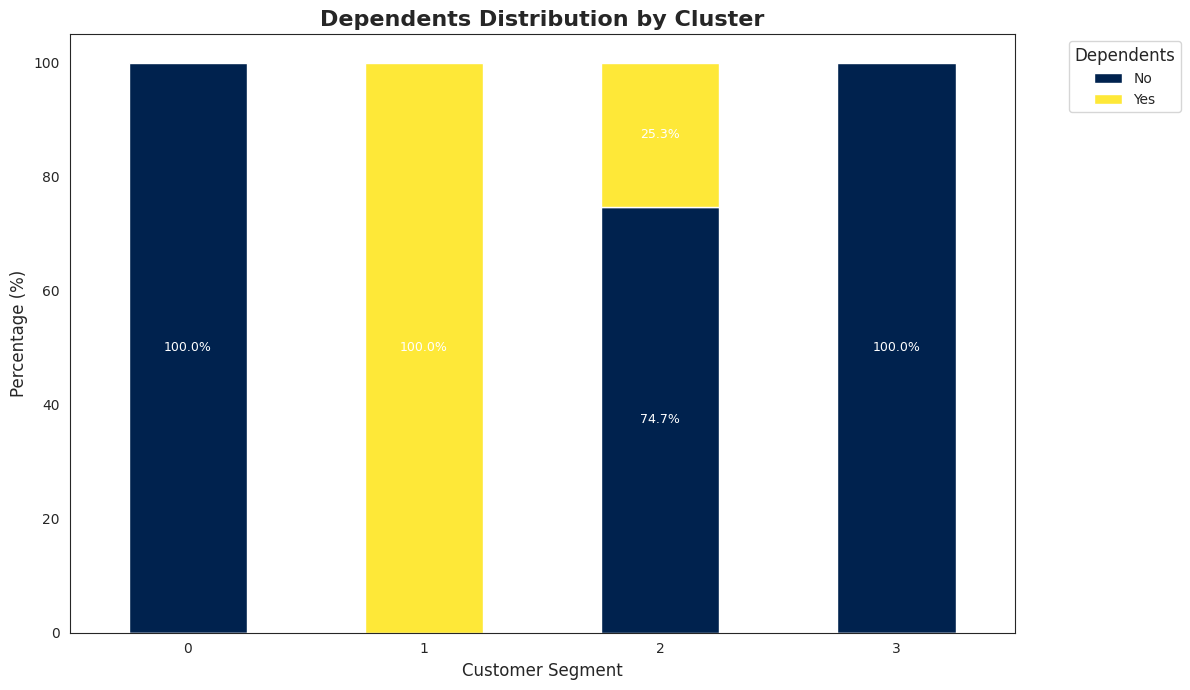

In [74]:
sns.set_style("white")

# Dependents Distribution by Cluster
dependents_by_cluster = (
    data.groupby('Cluster')['Dependents']
    .value_counts(normalize=True)
    .unstack(fill_value=0) * 100
)

fig, ax = plt.subplots(figsize=(12, 7))

dependents_by_cluster.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    cmap='cividis'
)

plt.title('Dependents Distribution by Cluster',
          fontsize=16, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.legend(
    title='Dependents',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    frameon=True,
    fontsize=10,
    title_fontsize=12
)

# addpercentage labels only when large enough to be readable
for container in ax.containers:
    labels = [
        f'{value:.1f}%' if value >= 5 else ''
        for value in container.datavalues
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type='center',
        fontsize=9,
        color='white'
    )

plt.tight_layout()
plt.show()

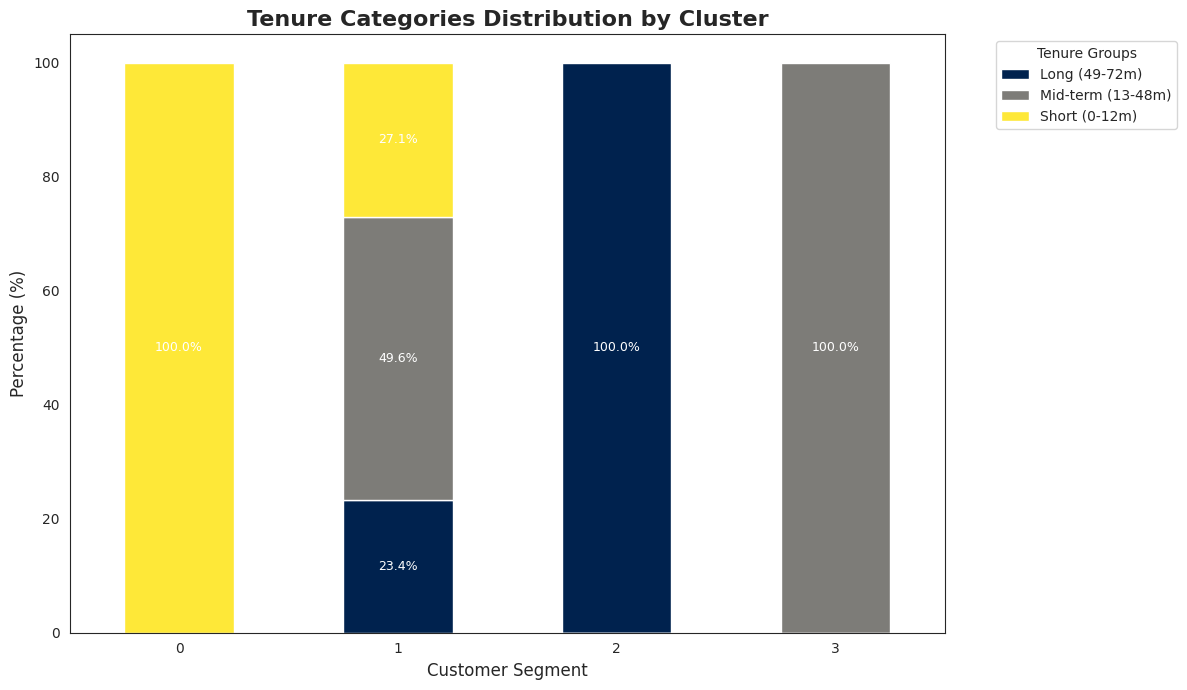

In [81]:
tenure_by_cluster = (
    data.groupby('Cluster')['Tenure_Groups']
    .value_counts(normalize=True)
    .unstack(fill_value=0) * 100
)

ax = tenure_by_cluster.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7),
    cmap='cividis'
)

plt.title('Tenure Categories Distribution by Cluster',
          fontsize=16, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(
    title='Tenure Groups',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

# Label only meaningful sections
for container in ax.containers:
    labels = [
        f'{v:.1f}%' if v >= 5 else ''
        for v in container.datavalues
    ]
    ax.bar_label(container, labels=labels, label_type='center',
                 fontsize=9, color= 'white')

plt.tight_layout()
plt.show()

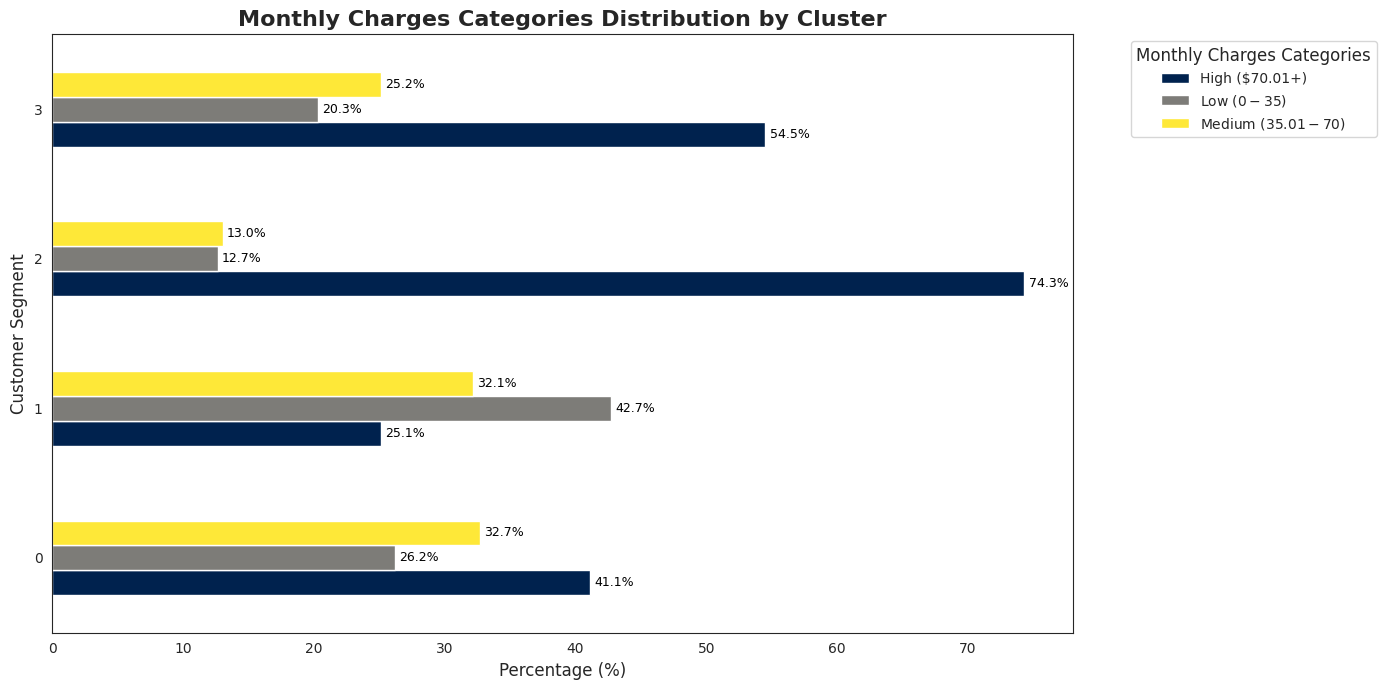

In [96]:
# Monthly Charges Categories Distribution by Cluster
monthly_charges_by_cluster = data.groupby('Cluster')['MonthlyCharges_Groups'].value_counts(normalize=True).unstack() * 100

fig = plt.figure(figsize=(14, 7))
ax = monthly_charges_by_cluster.plot(kind='barh', stacked=False, ax=plt.gca(), cmap='cividis')
plt.title('Monthly Charges Categories Distribution by Cluster', fontsize=16, fontweight='bold')
plt.xlabel('Percentage (%)', fontsize=12)
plt.ylabel('Customer Segment', fontsize=12)
plt.yticks(fontsize=10)
plt.xticks(fontsize=10)
plt.legend(title='Monthly Charges Categories', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, fontsize=10, title_fontsize=12)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9, color='black', padding=3, rotation=0)

plt.tight_layout()
plt.show()